# Stage 3 — Collaborative Multi-Agent DDPG Training (v2 Canonical)

**Purpose**: Train 8 collaborative DDPG pricing agents (P1 peak-valley + P2 load-balancing for each of 4 networks).

**Architecture note**: Following the base paper (*Lepolesa et al., IEEE Trans. Smart Grid, 2025*), DDPG agents learn pricing policies that target the same load/utilization-difference signals used in the closed-form EV demand formula. The headline evaluation metrics (Stage 4) use the formula directly; the DDPG pricing outputs are reported as supplementary evidence that an RL agent can learn a policy consistent with the optimal demand-shift behaviour.

**Key fix in v2**: P2 agents are trained on **distance-weighted** `util_diff_dist` (using `W_ij = exp(-α·d_ij)`), ensuring Gap 2 is properly wired into training.

In [1]:
# ============================================================
# CELL 1: IMPORTS AND DETERMINISTIC SEEDS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from collections import deque
import os, time, random, warnings

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# --- DETERMINISTIC SEEDS (set ONCE, never reset) ---
MASTER_SEED = 42
np.random.seed(MASTER_SEED)
random.seed(MASTER_SEED)
torch.manual_seed(MASTER_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MASTER_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

warnings.filterwarnings('ignore')
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print(f'Device: {dev}  |  Master seed: {MASTER_SEED}')

Device: cpu  |  Master seed: 42


In [2]:
# ============================================================
# CELL 2: SINGLE CANONICAL CONFIGURATION
# Every parameter used anywhere downstream is defined here ONCE.
# ============================================================

# --- Network topology ---
NETWORK_NAMES = ['residential', 'commercial', 'industrial', 'institutional']
NUM_NETWORKS  = len(NETWORK_NAMES)
NETWORK_MAX   = {                          # Maximum network capacity (W)
    'residential':   1_166_666,
    'commercial':    1_000_000,
    'industrial':    1_500_000,
    'institutional':   800_000,
}

# --- Distance decay (Gap 2) ---
ALPHA = 0.15                               # Spatial friction coefficient (1/km)

# --- Test window ---
TEST_START  = 192 * 3                      # Hour index 576
TEST_WINDOW = 24                           # 24-hour evaluation window

# --- DDPG hyperparameters (matching base paper architecture) ---
STATE_DIM       = 24
ACTION_DIM      = 24
LR_ACTOR        = 0.001
LR_CRITIC       = 0.002
GAMMA           = 0.99
TAU             = 0.005
BATCH_SIZE      = 64
NUM_EPISODES    = 300
CHECKPOINT_FREQ = 100
REPLAY_CAPACITY = 20_000
SAMPLES_PER_EP  = 30                       # 24-hour windows sampled per episode

# --- Conventional price schedule (base paper, Cell 17) ---
CONV_PRICES = np.array([
    0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,   # 12AM-6AM
    0.4, 0.7, 0.7,                          # 7AM-9AM
    0.7, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7, 0.7, # 10AM-5PM
    0.7, 1.0, 1.0, 1.0, 0.7, 0.7            # 6PM-11PM
])

# --- File paths ---
OUTPUT_DIR = 'data'
MODEL_DIR  = 'models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('Configuration loaded. All parameters defined in this cell only.')
print(f'Networks: {NETWORK_NAMES}')
print(f'DDPG: {NUM_EPISODES} episodes, batch={BATCH_SIZE}, lr_a={LR_ACTOR}, lr_c={LR_CRITIC}')
print(f'Distance decay: alpha={ALPHA}')

Configuration loaded. All parameters defined in this cell only.
Networks: ['residential', 'commercial', 'industrial', 'institutional']
DDPG: 300 episodes, batch=64, lr_a=0.001, lr_c=0.002
Distance decay: alpha=0.15


## Data Loading and Training Signal Preparation

In [3]:
# ============================================================
# CELL 3: LOAD DATA AND COMPUTE TRAINING SIGNALS
# ============================================================

# Full 8736-hour net load dataset (from Stages 0 + 0.75)
df_full_net = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_net_load.csv'))
print(f'Loaded n_network_net_load.csv: {df_full_net.shape}')

# Distance matrix (from Stage 0.5)
dist_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'network_distance_matrix.csv'), index_col=0)
dist_matrix = dist_df.values[:NUM_NETWORKS, :NUM_NETWORKS]

# Distance-decay weight matrix
W_mat = np.exp(-ALPHA * dist_matrix)
np.fill_diagonal(W_mat, 0.0)
print(f'Distance matrix (km):')
print(pd.DataFrame(np.round(dist_matrix, 2), index=NETWORK_NAMES, columns=NETWORK_NAMES).to_string())
print(f'\nWeight matrix W_ij = exp(-{ALPHA}*d):')
print(pd.DataFrame(np.round(W_mat, 4), index=NETWORK_NAMES, columns=NETWORK_NAMES).to_string())

# --- Compute distance-weighted util_diff_dist for P2 training ---
net_utils_full = {}
for name in NETWORK_NAMES:
    net_utils_full[name] = df_full_net[f'{name}_net_load'].values / NETWORK_MAX[name]

util_diff_dist_full = {}
for i, ni in enumerate(NETWORK_NAMES):
    all_utils = np.array([net_utils_full[nj] for nj in NETWORK_NAMES])  # (4, 8736)
    weighted_relief = np.average(all_utils, weights=W_mat[i], axis=0)
    util_diff_dist_full[ni] = np.clip(net_utils_full[ni] - weighted_relief, 0.0, None)

# --- Build normalized training signals ---
scaler = MinMaxScaler()
training_signals = {}
for name in NETWORK_NAMES:
    raw_load = df_full_net[f'{name}_net_load'].values.reshape(-1, 1)
    norm_load = scaler.fit_transform(raw_load).flatten()
    
    raw_diff_dist = util_diff_dist_full[name].reshape(-1, 1)
    norm_diff_dist = scaler.fit_transform(raw_diff_dist).flatten()
    
    training_signals[name] = {
        'norm_load': norm_load,
        'norm_diff_dist': norm_diff_dist,
    }

print(f'\nTraining signals prepared for {NUM_NETWORKS} networks across {len(df_full_net)} hours.')
print('P1 target: normalized net load (peak-valley flattening)')
print('P2 target: normalized distance-weighted util_diff_dist (inter-network balancing)')
for name in NETWORK_NAMES:
    nd = training_signals[name]['norm_diff_dist']
    print(f'  {name}: diff_dist nonzero hours = {np.sum(nd > 0.01)}, max = {nd.max():.4f}')

Loaded n_network_net_load.csv: (8736, 29)
Distance matrix (km):
               residential  commercial  industrial  institutional
residential           0.00        1.16        5.52           1.54
commercial            1.16        0.00        5.15           2.28
industrial            5.52        5.15        0.00           7.06
institutional         1.54        2.28        7.06           0.00

Weight matrix W_ij = exp(-0.15*d):
               residential  commercial  industrial  institutional
residential         0.0000      0.8407      0.4371         0.7940
commercial          0.8407      0.0000      0.4622         0.7106
industrial          0.4371      0.4622      0.0000         0.3471
institutional       0.7940      0.7106      0.3471         0.0000

Training signals prepared for 4 networks across 8736 hours.
P1 target: normalized net load (peak-valley flattening)
P2 target: normalized distance-weighted util_diff_dist (inter-network balancing)
  residential: diff_dist nonzero hours = 4

## Neural Network Architecture

In [4]:
# ============================================================
# CELL 4: ACTOR / CRITIC / DDPG AGENT
# Architecture: Base paper (Lepolesa et al., 2025)
#   Actor:  24 -> 64 -> 64 -> 24, Tanh output scaled to [0,1]
#   Critic: 48 -> 64 -> 64 -> 1
# ============================================================

class Actor(nn.Module):
    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),        nn.ReLU(),
            nn.Linear(64, action_dim), nn.Tanh()
        )
    def forward(self, x):
        return (self.net(x) + 1) / 2  # Scale from [-1,1] to [0,1]

class Critic(nn.Module):
    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),                      nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

class DDPGAgent:
    def __init__(self):
        self.actor  = Actor().to(dev)
        self.critic = Critic().to(dev)
        self.target_actor  = Actor().to(dev)
        self.target_critic = Critic().to(dev)
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.target_critic.load_state_dict(self.critic.state_dict())
        self.actor_opt  = optim.Adam(self.actor.parameters(),  lr=LR_ACTOR)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=LR_CRITIC)

    def select_action(self, state):
        with torch.no_grad():
            s = torch.FloatTensor(state).to(dev).unsqueeze(0)
            return self.actor(s).cpu().numpy()[0]

    def update(self, replay_buffer):
        if len(replay_buffer) < BATCH_SIZE:
            return 0.0, 0.0
        idx = np.random.choice(len(replay_buffer), BATCH_SIZE, replace=False)
        batch = [replay_buffer[i] for i in idx]
        states, actions, rewards, next_states = zip(*batch)
        s  = torch.FloatTensor(np.array(states)).to(dev)
        a  = torch.FloatTensor(np.array(actions)).to(dev)
        r  = torch.FloatTensor(np.array(rewards)).to(dev).unsqueeze(1)
        ns = torch.FloatTensor(np.array(next_states)).to(dev)
        # Critic update
        na = self.target_actor(ns)
        tq = r + GAMMA * self.target_critic(ns, na).detach()
        qv = self.critic(s, a)
        cl = F.mse_loss(qv, tq)
        self.critic_opt.zero_grad(); cl.backward(); self.critic_opt.step()
        # Actor update
        al = -self.critic(s, self.actor(s)).mean()
        self.actor_opt.zero_grad(); al.backward(); self.actor_opt.step()
        # Soft target update
        for p, tp in zip(self.actor.parameters(), self.target_actor.parameters()):
            tp.data.copy_(TAU * p.data + (1 - TAU) * tp.data)
        for p, tp in zip(self.critic.parameters(), self.target_critic.parameters()):
            tp.data.copy_(TAU * p.data + (1 - TAU) * tp.data)
        return al.item(), cl.item()

def save_agent(agent, path):
    torch.save({
        'actor': agent.actor.state_dict(),
        'critic': agent.critic.state_dict(),
        'actor_opt': agent.actor_opt.state_dict(),
        'critic_opt': agent.critic_opt.state_dict(),
    }, path)

def load_agent(agent, path):
    ckpt = torch.load(path, map_location=dev)
    agent.actor.load_state_dict(ckpt['actor'])
    agent.critic.load_state_dict(ckpt['critic'])
    agent.actor_opt.load_state_dict(ckpt['actor_opt'])
    agent.critic_opt.load_state_dict(ckpt['critic_opt'])

print('Actor/Critic/DDPGAgent defined. Architecture matches base paper.')

Actor/Critic/DDPGAgent defined. Architecture matches base paper.


## Training Loop

In [5]:
# ============================================================
# CELL 5: TRAINING FUNCTION
# ============================================================

def train_agent(agent_name, state_series, target_series):
    """Train one DDPG agent on sequential 24-hour windows."""
    agent = DDPGAgent()
    replay_buffer = deque(maxlen=REPLAY_CAPACITY)
    ep_rewards, ep_alosses, ep_closses = [], [], []
    max_start = len(state_series) - 48
    t0 = time.time()
    
    for ep in range(1, NUM_EPISODES + 1):
        total_r = 0.0; alosses = []; closses = []
        for _ in range(SAMPLES_PER_EP):
            idx = np.random.randint(0, max_start)
            state = state_series[idx:idx+24]
            action = agent.select_action(state)
            target_val = target_series[idx+1:idx+25]
            reward = -np.mean(np.abs(action - target_val))
            next_state = state_series[idx+1:idx+25]
            replay_buffer.append((state, action, reward, next_state))
            total_r += reward
            if len(replay_buffer) >= BATCH_SIZE:
                al, cl = agent.update(replay_buffer)
                alosses.append(al); closses.append(cl)
        ep_rewards.append(total_r / SAMPLES_PER_EP)
        ep_alosses.append(np.mean(alosses) if alosses else 0.0)
        ep_closses.append(np.mean(closses) if closses else 0.0)
        if ep % CHECKPOINT_FREQ == 0 or ep == NUM_EPISODES:
            save_agent(agent, os.path.join(MODEL_DIR, f'ddpg_{agent_name}.pth'))
    
    elapsed = time.time() - t0
    print(f'  [{agent_name:<22}] {NUM_EPISODES} eps ({elapsed:.1f}s) | '
          f'Final reward: {ep_rewards[-1]:.4f} | Saved: ddpg_{agent_name}.pth')
    return agent, {'reward': ep_rewards, 'actor_loss': ep_alosses, 'critic_loss': ep_closses}

print('Training function defined.')

Training function defined.


In [6]:
# ============================================================
# CELL 6: TRAIN ALL 8 AGENTS
# P1: state=norm_net_load, target=norm_net_load (peak-valley)
# P2: state=norm_net_load, target=norm_diff_DIST (balancing)
# ============================================================

trained_agents = {}
training_histories = {}

print('='*70)
print(f'TRAINING {NUM_NETWORKS * 2} COLLABORATIVE DDPG PRICING AGENTS')
print('='*70)

for name in NETWORK_NAMES:
    nl = training_signals[name]['norm_load']
    nd = training_signals[name]['norm_diff_dist']
    
    # P1: Peak-Valley (targets own load)
    a1, h1 = train_agent(f'{name}_p1', nl, nl)
    trained_agents[f'{name}_p1'] = a1
    training_histories[f'{name}_p1'] = h1
    
    # P2: Load Balancing (targets distance-weighted util_diff)
    a2, h2 = train_agent(f'{name}_p2', nl, nd)
    trained_agents[f'{name}_p2'] = a2
    training_histories[f'{name}_p2'] = h2

print('='*70)
print('All 8 agents trained and checkpointed.')

TRAINING 8 COLLABORATIVE DDPG PRICING AGENTS


  [residential_p1        ] 300 eps (8.8s) | Final reward: -0.1315 | Saved: ddpg_residential_p1.pth


  [residential_p2        ] 300 eps (8.9s) | Final reward: -0.0946 | Saved: ddpg_residential_p2.pth


  [commercial_p1         ] 300 eps (8.8s) | Final reward: -0.1553 | Saved: ddpg_commercial_p1.pth


  [commercial_p2         ] 300 eps (8.9s) | Final reward: -0.1218 | Saved: ddpg_commercial_p2.pth


  [industrial_p1         ] 300 eps (8.7s) | Final reward: -0.1234 | Saved: ddpg_industrial_p1.pth


  [industrial_p2         ] 300 eps (8.8s) | Final reward: -0.1234 | Saved: ddpg_industrial_p2.pth


  [institutional_p1      ] 300 eps (8.6s) | Final reward: -0.1273 | Saved: ddpg_institutional_p1.pth


  [institutional_p2      ] 300 eps (9.1s) | Final reward: -0.1120 | Saved: ddpg_institutional_p2.pth
All 8 agents trained and checkpointed.


## Training Diagnostics

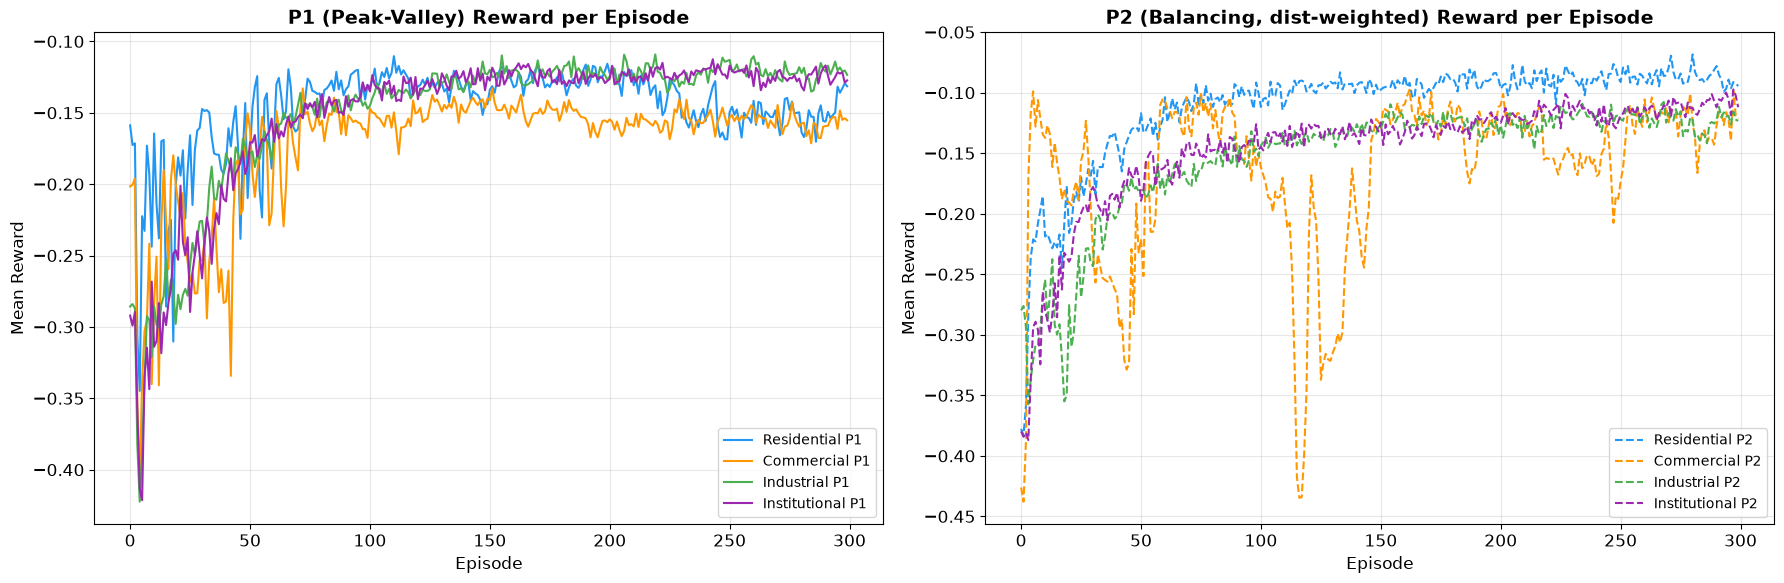


=== TRAINING DIAGNOSTICS ===
  commercial_p1         : CV=24.9%  min=-0.4097  max=-0.1329  early=-0.2879  late=-0.1553
  commercial_p2         : CV=41.2%  min=-0.4379  max=-0.0975  early=-0.2130  late=-0.1203
  industrial_p1         : CV=35.3%  min=-0.4224  max=-0.1092  early=-0.3294  late=-0.1198
  industrial_p2         : CV=33.5%  min=-0.3574  max=-0.1077  early=-0.3047  late=-0.1198
  institutional_p1      : CV=35.5%  min=-0.4214  max=-0.1125  early=-0.3336  late=-0.1246
  institutional_p2      : CV=33.7%  min=-0.3869  max=-0.0973  early=-0.3337  late=-0.1063
  residential_p1        : CV=21.2%  min=-0.3448  max=-0.1103  early=-0.2219  late=-0.1422
  residential_p2        : CV=40.1%  min=-0.3830  max=-0.0685  early=-0.2673  late=-0.0912


In [7]:
# ============================================================
# CELL 7: TRAINING REWARD CURVES AND DIAGNOSTICS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for idx, name in enumerate(NETWORK_NAMES):
    axes[0].plot(training_histories[f'{name}_p1']['reward'],
                 color=colors[idx], label=f'{name.capitalize()} P1')
    axes[1].plot(training_histories[f'{name}_p2']['reward'],
                 color=colors[idx], linestyle='--', label=f'{name.capitalize()} P2')

axes[0].set_title('P1 (Peak-Valley) Reward per Episode', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Mean Reward')
axes[0].legend(fontsize=10)
axes[1].set_title('P2 (Balancing, dist-weighted) Reward per Episode', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Mean Reward')
axes[1].legend(fontsize=10)
plt.tight_layout(); plt.show()

print('\n=== TRAINING DIAGNOSTICS ===')
for key in sorted(training_histories.keys()):
    r = np.array(training_histories[key]['reward'])
    cv = r.std() / abs(r.mean()) * 100
    print(f'  {key:<22}: CV={cv:.1f}%  min={r.min():.4f}  max={r.max():.4f}  '
          f'early={r[:10].mean():.4f}  late={r[-10:].mean():.4f}')

## Test Window: DDPG Pricing Output (Supplementary)

In [8]:
# ============================================================
# CELL 8: GENERATE DYNAMIC PRICES ON TEST WINDOW
# ============================================================

# Load test data
df_test = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_24h_test.csv'))
hours = np.arange(TEST_WINDOW)

# Generate actions from trained agents
actions_p1 = {}
actions_p2 = {}
ev_dynamic_prices = {}

for name in NETWORK_NAMES:
    # State: normalized net load on test window
    test_net_load = df_test[f'{name}_net_load'].values
    sc = MinMaxScaler()
    test_state = sc.fit_transform(test_net_load.reshape(-1, 1)).flatten()
    
    actions_p1[name] = trained_agents[f'{name}_p1'].select_action(test_state)
    actions_p2[name] = trained_agents[f'{name}_p2'].select_action(test_state)
    
    # Dynamic EV price: conv_price + 0.5*(action_p1 + action_p2)
    ev_dynamic_prices[name] = CONV_PRICES + 0.5 * (actions_p1[name] + actions_p2[name])

print('Dynamic prices generated from trained DDPG agents.')
print('NOTE: These prices demonstrate the RL policy; headline metrics in Stage 4')
print('      use the closed-form demand formula, consistent with base paper methodology.')

Dynamic prices generated from trained DDPG agents.
NOTE: These prices demonstrate the RL policy; headline metrics in Stage 4
      use the closed-form demand formula, consistent with base paper methodology.


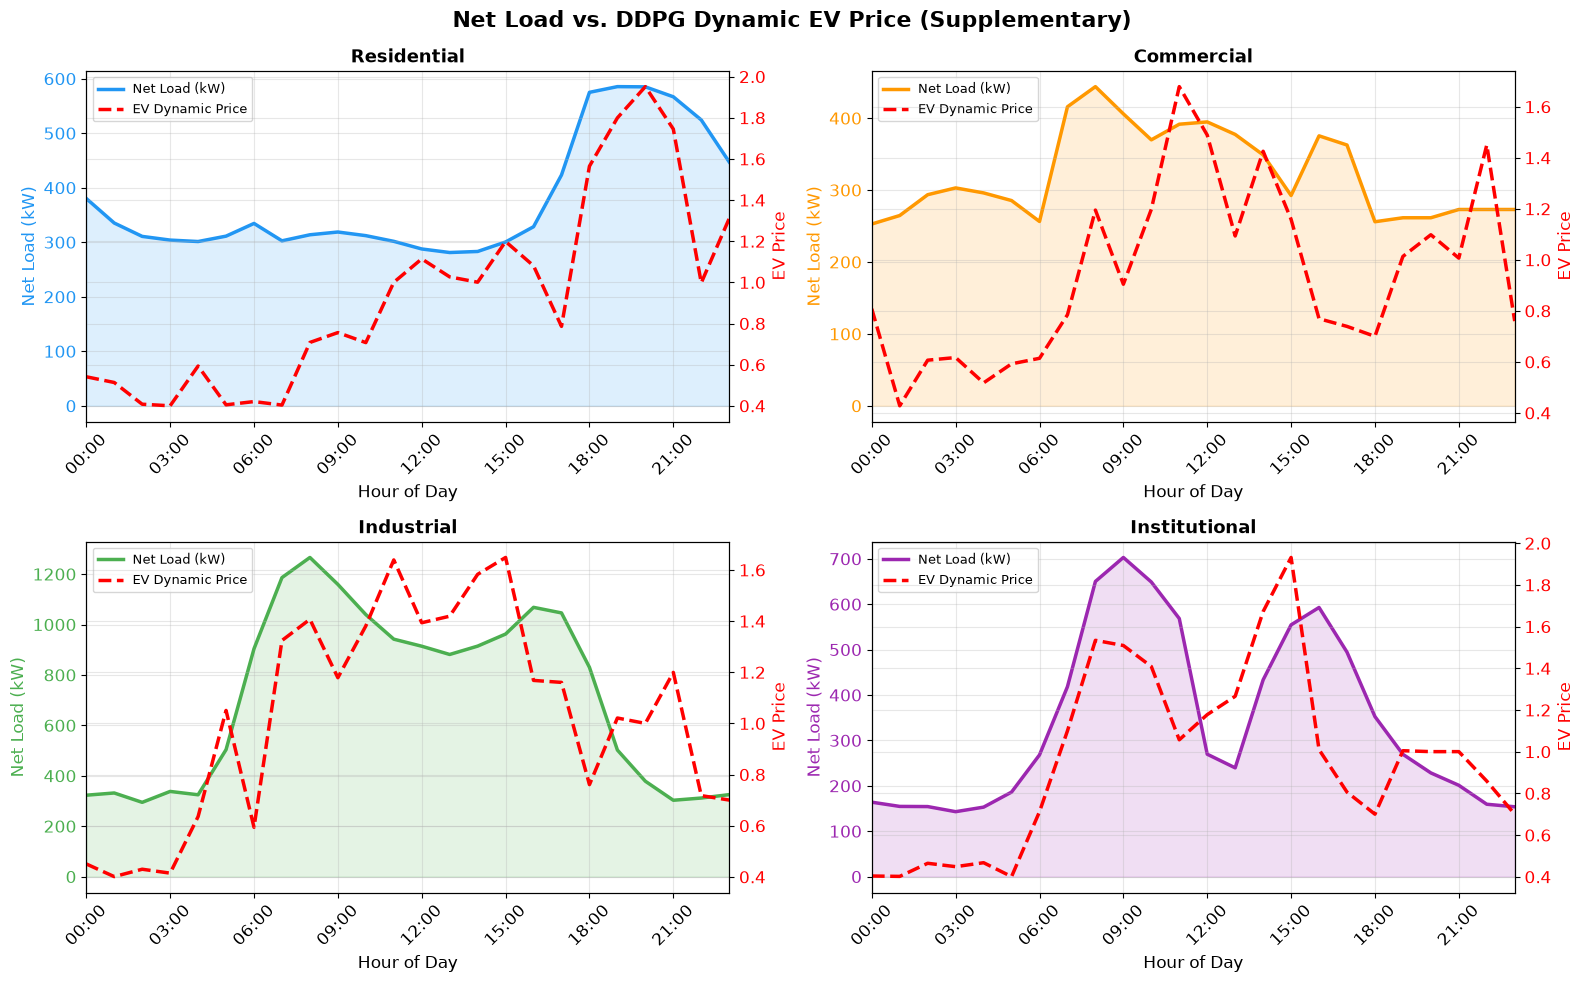

In [9]:
# ============================================================
# CELL 9: PRICE VS LOAD OVERLAY PLOTS (Base paper style)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Net Load vs. DDPG Dynamic EV Price (Supplementary)', fontsize=16, fontweight='bold')

for idx, (name, color) in enumerate(zip(NETWORK_NAMES, colors)):
    ax1 = axes[idx // 2, idx % 2]
    load_kw = df_test[f'{name}_net_load'].values / 1000
    line1, = ax1.plot(hours, load_kw, color=color, linewidth=2.5, label='Net Load (kW)')
    ax1.fill_between(hours, load_kw, color=color, alpha=0.15)
    ax1.set_xlabel('Hour of Day'); ax1.set_ylabel('Net Load (kW)', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(hours[::3])
    ax1.set_xticklabels([f'{h:02d}:00' for h in hours[::3]], rotation=45)
    
    ax2 = ax1.twinx()
    line2, = ax2.plot(hours, ev_dynamic_prices[name], color='red', linestyle='--', linewidth=2.5, label='EV Dynamic Price')
    ax2.set_ylabel('EV Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax1.set_title(f'{name.capitalize()}', fontsize=13, fontweight='bold')
    ax1.legend([line1, line2], ['Net Load (kW)', 'EV Dynamic Price'], loc='upper left', fontsize=9)
    ax1.set_xlim(0, 23)

plt.tight_layout(); plt.show()

## Export

In [10]:
# ============================================================
# CELL 10: EXPORT ALL ARTIFACTS
# ============================================================

# 1. Dynamic prices CSV
df_prices = pd.DataFrame({'Hour': hours})
for name in NETWORK_NAMES:
    df_prices[f'{name}_action_p1'] = actions_p1[name]
    df_prices[f'{name}_action_p2'] = actions_p2[name]
    df_prices[f'{name}_ev_dynamic_price'] = ev_dynamic_prices[name]
prices_path = os.path.join(OUTPUT_DIR, 'ddpg_dynamic_prices_v2.csv')
df_prices.to_csv(prices_path, index=False)
print(f'1. Written: {prices_path}')

# 2. Training stats CSV
df_stats = pd.DataFrame({'Episode': range(1, NUM_EPISODES + 1)})
for key, hist in sorted(training_histories.items()):
    df_stats[f'{key}_reward'] = hist['reward']
    df_stats[f'{key}_actor_loss'] = hist['actor_loss']
    df_stats[f'{key}_critic_loss'] = hist['critic_loss']
stats_path = os.path.join(OUTPUT_DIR, 'ddpg_training_stats_v2.csv')
df_stats.to_csv(stats_path, index=False)
print(f'2. Written: {stats_path}')

# 3. Verify all 8 checkpoints exist
print('\n=== MODEL CHECKPOINTS ===')
for name in NETWORK_NAMES:
    for role in ['p1', 'p2']:
        path = os.path.join(MODEL_DIR, f'ddpg_{name}_{role}.pth')
        exists = os.path.exists(path)
        size_kb = os.path.getsize(path) / 1024 if exists else 0
        status = f'{size_kb:.0f} KB' if exists else 'MISSING'
        print(f'  ddpg_{name}_{role}.pth: {status}')

print('\nStage 3 complete.')

1. Written: data/ddpg_dynamic_prices_v2.csv
2. Written: data/ddpg_training_stats_v2.csv

=== MODEL CHECKPOINTS ===
  ddpg_residential_p1.pth: 187 KB
  ddpg_residential_p2.pth: 187 KB
  ddpg_commercial_p1.pth: 187 KB
  ddpg_commercial_p2.pth: 187 KB
  ddpg_industrial_p1.pth: 187 KB
  ddpg_industrial_p2.pth: 187 KB
  ddpg_institutional_p1.pth: 187 KB
  ddpg_institutional_p2.pth: 187 KB

Stage 3 complete.
